# **Smart Irrigation Analytics: Data-Driven Insights for Efficient Water Management**

**🌱 Business Problem Statement**

Efficient water management is a critical challenge in agriculture due to increasing water scarcity and changing climatic conditions. Farmers often struggle to determine the appropriate amount of irrigation required for different crops under varying soil and environmental conditions.

This project aims to analyze agricultural data—including soil properties, weather conditions, crop types, and irrigation practices—to understand the key factors influencing irrigation requirements. The goal is to generate insights that can help optimize water usage, reduce wastage, and support better decision-making in irrigation planning.

**Objective of the Analysis**

The objective of this analysis is to explore and understand how soil characteristics, weather conditions, crop types, and irrigation practices influence the irrigation requirements of agricultural fields. The study aims to identify key factors affecting irrigation need and extract meaningful insights that can support efficient water management and better decision-making in agriculture.

In [ ]:
# Import required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [ ]:
# Let us Load the data
df=pd.read_csv("/content/irrigation_uncleaned_4cols_nulls.csv")
df.shape

(10000, 20)

# **Data Understanding**

In [ ]:
# Let us display the basic information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 20 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Soil_Type                9200 non-null   object 
 1   Soil_pH                  9200 non-null   float64
 2   Soil_Moisture            9200 non-null   float64
 3   Organic_Carbon           9200 non-null   float64
 4   Electrical_Conductivity  10000 non-null  float64
 5   Temperature_C            10000 non-null  float64
 6   Humidity                 10000 non-null  float64
 7   Rainfall_mm              10000 non-null  float64
 8   Sunlight_Hours           10000 non-null  float64
 9   Wind_Speed_kmh           10000 non-null  float64
 10  Crop_Type                10000 non-null  object 
 11  Crop_Growth_Stage        10000 non-null  object 
 12  Season                   10000 non-null  object 
 13  Irrigation_Type          10000 non-null  object 
 14  Water_Source           

In [ ]:
# Let us display the first few columns of the dataset
df.head()

,Soil_Type,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,Wind_Speed_kmh,Crop_Type,Crop_Growth_Stage,Season,Irrigation_Type,Water_Source,Field_Area_hectare,Mulching_Used,Previous_Irrigation_mm,Region,Irrigation_Need
0,Clay,6.14,36.48,0.42,2.17,21.90,31.19,1167.70,4.01,1.97,Wheat,Vegetative,Rabi,Rainfed,Reservoir,4.73,Yes,1.98,South,Low
1,Silt,6.41,50.56,0.38,0.23,36.50,26.01,831.28,10.72,16.82,Maize,Flowering,Zaid,Canal,Groundwater,12.22,Yes,33.56,Central,Medium
2,Sandy,7.71,40.07,NaN,2.18,41.83,76.41,1844.45,7.75,19.03,Cotton,Harvest,Rabi,Drip,Reservoir,5.52,Yes,34.62,South,Low
3,Clay,5.96,12.75,1.56,0.40,37.22,43.32,306.26,8.90,11.44,Wheat,Sowing,Kharif,Canal,Reservoir,1.43,Yes,84.03,North,Medium
4,Clay,7.76,18.58,0.95,2.52,22.38,86.44,1875.63,10.39,11.26,Cotton,Sowing,Zaid,Canal,River,2.52,No,60.86,South,Medium


**Observations:**
- The Dataset contains 10000 Rows and 20 columns.
- Categorical data columns are 9 and Real Numerical data column are 11.
- Categorical data columns are -> Soil_type,crop_type,crop_growth_stage,season,irrigation_type,water_sourse ,mulching_used,Region and **Irrigation_Need**.

- Real Numerical Data columns are : Soil_PH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,Wind_Speed_kmh,	Field_Area_hectare, Previous_Irrigation_mm.

Target variable : **Irrigation_Need**


# **Data Cleaning**

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
#  Identify the missing values in the dataset
df.isnull().sum()

,0
Soil_Type,800
Soil_pH,800
Soil_Moisture,800
Organic_Carbon,800
Electrical_Conductivity,0
Temperature_C,0
Humidity,0
Rainfall_mm,0
Sunlight_Hours,0
Wind_Speed_kmh,0


**Observations:**
- Missing values exist in Soil_Type, Soil_pH, Soil_Moisture, and Organic_Carbon.

Interpretation:
- These fields are important soil indicators, so missing values must be handled carefully.

In [ ]:
# Percentage of missing values
((df.isnull().sum())/len(df))*100

,0
Soil_Type,8.0
Soil_pH,8.0
Soil_Moisture,8.0
Organic_Carbon,8.0
Electrical_Conductivity,0.0
Temperature_C,0.0
Humidity,0.0
Rainfall_mm,0.0
Sunlight_Hours,0.0
Wind_Speed_kmh,0.0


**Observations:**
- Soil_Type is categorical column has 8% missing values so we can use simple imputation method "**Mode()**".
- Soil_PH,Soil_Moisture,Organic_Carbon are Real Numerical data columns all are having 8% missing values ,so that we can use aimple imputation method "**Mean()**",if outliers are present we can use **median()**.

**Handling Missing Values**

In [ ]:
# Handling the missing values  on Categorical column 'Soil_Type'
df["Soil_Type"] = df["Soil_Type"].fillna(df["Soil_Type"].mode()[0])


In [ ]:
# Handling missing values on Real Numerical Data columns
df["Soil_pH"] = df["Soil_pH"].fillna(df["Soil_pH"].mean())
df["Soil_Moisture"] = df["Soil_Moisture"].fillna(df["Soil_Moisture"].mean())
df["Organic_Carbon"] = df["Organic_Carbon"].fillna(df["Organic_Carbon"].mean())

**Observations:**
- Here we can use mode() for Categorical data column "Soil_Type"
- we used Mean() for Real Numerical Data columns "Soil_PH","Soil_Moisture","Organic_Carbon".

# **Data Preparation**

**Target Column Analysis**

In [ ]:
# Let us find frequency of the column "Irrigation_Need"
df["Irrigation_Need"].value_counts()

,count
Irrigation_Need,
Low,5864
Medium,3800
High,336


**Observation:**
- Most farms do not need immediate irrigation (Low), while Medium and High together show many farms require irrigation support.
- Medium and High categories were combined because both indicate farms that need irrigation support.

In [ ]:
# To Combine Medium and High categories of the column "Irrigation_Need".
df["Need_Irrigation"]=df["Irrigation_Need"].replace({'Low':'No','Medium':'Yes','High':'Yes'})

In [ ]:
df["Need_Irrigation"].value_counts()

,count
Need_Irrigation,
No,5864
Yes,4136


**Observation:**
- After combining Medium and High, many farms need irrigation (Yes), while the remaining farms do not need immediate irrigation (No). The target data is now more balanced.

In [ ]:
# Drop the column "Irrigation_Need"
df.drop(columns="Irrigation_Need",inplace=True)

In [ ]:
# Let us Drop unnecessary columns
df.drop(columns = ["Mulching_Used","Field_Area_hectare","Electrical_Conductivity","Organic_Carbon","Wind_Speed_kmh","Water_Source"],inplace = True)
df

,Soil_Type,Soil_pH,Soil_Moisture,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,Crop_Type,Crop_Growth_Stage,Season,Irrigation_Type,Previous_Irrigation_mm,Region,Need_Irrigation
0,Clay,6.14,36.48,21.90,31.19,1167.70,4.01,Wheat,Vegetative,Rabi,Rainfed,1.98,South,No
1,Silt,6.41,50.56,36.50,26.01,831.28,10.72,Maize,Flowering,Zaid,Canal,33.56,Central,Yes
2,Sandy,7.71,40.07,41.83,76.41,1844.45,7.75,Cotton,Harvest,Rabi,Drip,34.62,South,No
3,Clay,5.96,12.75,37.22,43.32,306.26,8.90,Wheat,Sowing,Kharif,Canal,84.03,North,Yes
4,Clay,7.76,18.58,22.38,86.44,1875.63,10.39,Cotton,Sowing,Zaid,Canal,60.86,South,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,Silt,7.01,26.67,27.61,52.20,1075.12,7.41,Sugarcane,Sowing,Kharif,Drip,92.44,South,No
9996,Clay,5.40,49.44,34.03,52.31,1591.84,9.86,Maize,Sowing,Kharif,Rainfed,15.46,South,No
9997,Sandy,4.97,60.63,36.68,68.16,2384.87,10.75,Potato,Harvest,Kharif,Canal,116.36,North,No
9998,Loamy,7.12,44.33,31.50,64.83,2397.01,4.03,Sugarcane,Harvest,Kharif,Rainfed,118.17,East,No


**Statistical Analysis**

In [ ]:
df.describe()

,Soil_pH,Soil_Moisture,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,Previous_Irrigation_mm
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,6.491163,37.026637,26.991423,60.080339,1252.499420,7.518538,59.864122
std,0.941438,15.760140,8.664074,20.187973,715.582201,2.016077,34.483722
min,4.800000,8.000000,12.000000,25.000000,0.380000,4.000000,0.020000
25%,5.720000,24.360000,19.460000,42.855000,634.155000,5.760000,30.160000
50%,6.491163,37.026637,27.090000,60.040000,1250.335000,7.560000,59.630000
75%,7.260000,49.832500,34.500000,77.705000,1880.265000,9.260000,90.030000
max,8.200000,64.990000,42.000000,95.000000,2499.690000,11.000000,119.990000


**Observations:**
- Rainfall and Soil_moisture show high variability.
- Temperature and sunlight indicate strong evaporation conditions in some areas.


# **Outlier Detection**

<Axes: ylabel='Region'>

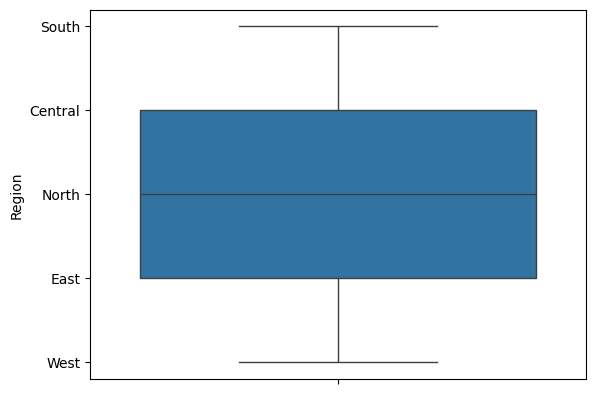

In [ ]:
sns.boxplot(df["Region"])

Observations:
- There are no sinificant outliers present in the dataset, that means all values lie with in the acceptable IQR range and no outliers are visible in the Box plot.

# **Group Based Analysis**

In [ ]:
# groupby(): Apply groupby to 'Region' over 'Need_Irrigation'
df.groupby("Region")["Need_Irrigation"].value_counts()

Region   Need_Irrigation
Central  No                 1173
         Yes                 814
East     No                 1178
         Yes                 816
North    No                 1084
         Yes                 816
South    No                 1239
         Yes                 863
West     No                 1190
         Yes                 827
Name: count, dtype: int64

**Observations:**

The South region has the highest number of records for both
- No Irrigation Need
- Yes Irrigation Need

**Insight:**
- Farms(Agricultural Lands) in the South region experience both sufficient and insufficient water conditions, resulting in higher records for both irrigation categories.



In [ ]:
# groupby(): Apply group by to 'Soil_Type' over 'Need_Irrigation'
df.groupby("Soil_Type")["Need_Irrigation"].value_counts()

Soil_Type  Need_Irrigation
Clay       No                 1324
           Yes                 930
Loamy      No                 1382
           Yes                 928
Sandy      No                 1820
           Yes                1308
Silt       No                 1338
           Yes                 970
Name: count, dtype: int64

**Observation:**
- Sandy soil has the highest number of records where additional irrigation is required.

**Insight:**
- Sandy soil may require more irrigation due to its low water retention capacity.

In [ ]:
# groupby() : Apply groupby() to "Crop_Type" over "Need_Irrigation"
df.groupby("Crop_Type")["Need_Irrigation"].value_counts()

Crop_Type  Need_Irrigation
Cotton     No                  928
           Yes                 667
Maize      No                  976
           Yes                 718
Potato     No                  954
           Yes                 709
Rice       No                 1030
           Yes                 681
Sugarcane  No                  987
           Yes                 691
Wheat      No                  989
           Yes                 670
Name: count, dtype: int64

**Observation:**
- Some crop types have a higher number of records where irrigation is needed compared to others.

**Insight:**
- Irrigation requirements vary depending on crop type, as different crops require different amounts of water for growth.

In [ ]:
# Distribution between two categorical columns
pd.crosstab(df['Season'],df['Need_Irrigation'])

Need_Irrigation,No,Yes
Season,,
Kharif,1947,1415
Rabi,2016,1367
Zaid,1901,1354


**Observation**


- The Kharif season has the highest number of records where irrigation is needed.


**Insight**


- Irrigation requirements vary across seasons due to differences in climate and rainfall conditions.



# **Visualization Analysis**

Text(0.5, 1.0, 'Distribution of Need_irrigation')

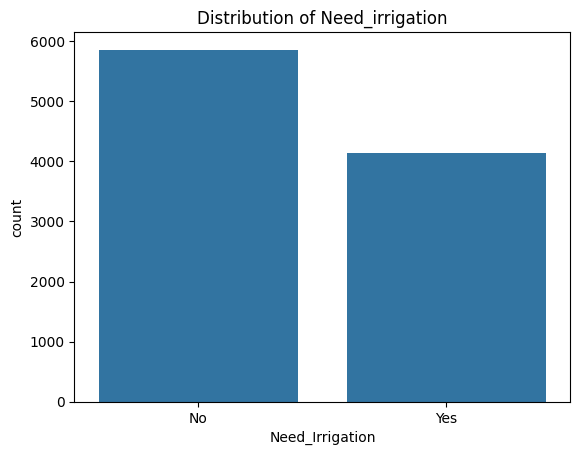

In [ ]:
# Target variable distribution

sns.countplot(df,x="Need_Irrigation")
plt.title("Distribution of Need_irrigation")

<Axes: ylabel='count'>

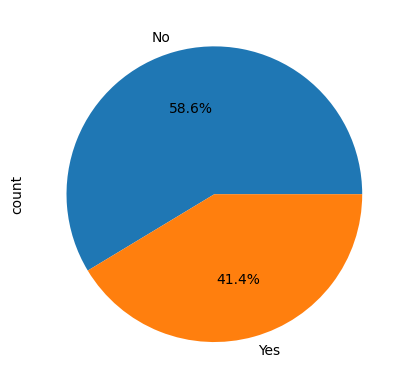

In [ ]:
# Pie Chart
df["Need_Irrigation"].value_counts().head(4).plot(kind="pie",autopct = "%1.1f%%")

**Observation:**
- Majority of farms (58.6%) do not require irrigation, while 41.4% require irrigation support.

**Insight:**
- Although most farms have sufficient water availability, a considerable portion still depends on irrigation, indicating the importance of efficient water management practices.

# **BiVariate Analysis:**

**Relationship Between Soil Moisture and Need_Irrigation**
- Soil_Moisture is Numerical column and Need_Irrigation is  Catrgorical column
- Suitable plots are  -> Box plot and Bar Plot

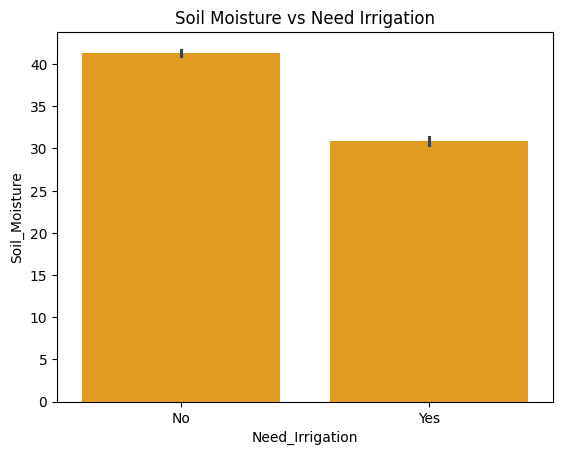

In [ ]:
sns.barplot(data=df,x = "Need_Irrigation",y = "Soil_Moisture",color = "Orange")
plt.title("Soil Moisture vs Need Irrigation")
plt.show()


**Observations:**
- Farms with low soil moisture mostly require irrigation.
- Farms with higher soil moisture generally do not require irrigation.

Insight:
- Soil moisture is **inversely** proportional to irrigation requirement.
	​
- Lower soil moisture indicates insufficient water availability in soil, increasing irrigation demand.

**Relationship between Rainfall_mm and Need_Irrigation:**
- Rainfall_mm is Numerical column and Need_Irrigation is Categorical COlumn
- Suitable plots are -> Bor Plot and Box Plot

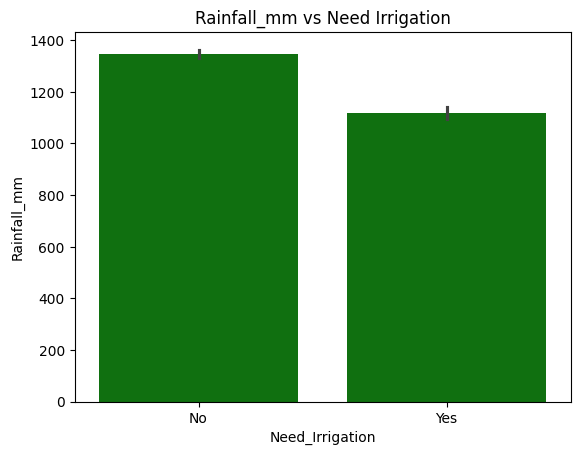

In [ ]:
sns.barplot(data=df,x = "Need_Irrigation",y = "Rainfall_mm",color = "Green")
plt.title("Rainfall_mm vs Need Irrigation")
plt.show()

**Observations:**
- Farms receiving lower rainfall mostly require irrigation.
- Higher rainfall areas show reduced irrigation need.

**Insights:**
- Rainfall significantly reduces irrigation dependency (Need Irrigation is **inversily** proportional to RainFall).
- Natural rainfall supplies water to crops, reducing artificial irrigation requirements.

**Multivariate Analysis:**

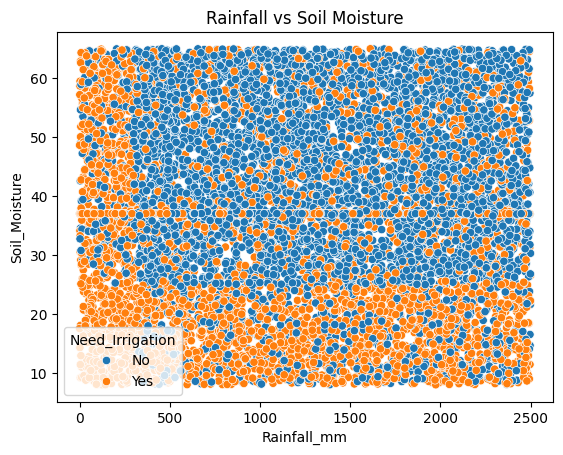

In [ ]:
sns.scatterplot(data=df,
                x="Rainfall_mm",
                y="Soil_Moisture",
                hue="Need_Irrigation")

plt.title("Rainfall vs Soil Moisture")
plt.show()

**Observations:**
High temperature and low soil moisture mostly lead to irrigation requirement.
Seasonal variations also affect irrigation dependency.

**Insight:**

Multiple environmental factors collectively influence irrigation decisions.

**PairPlot**

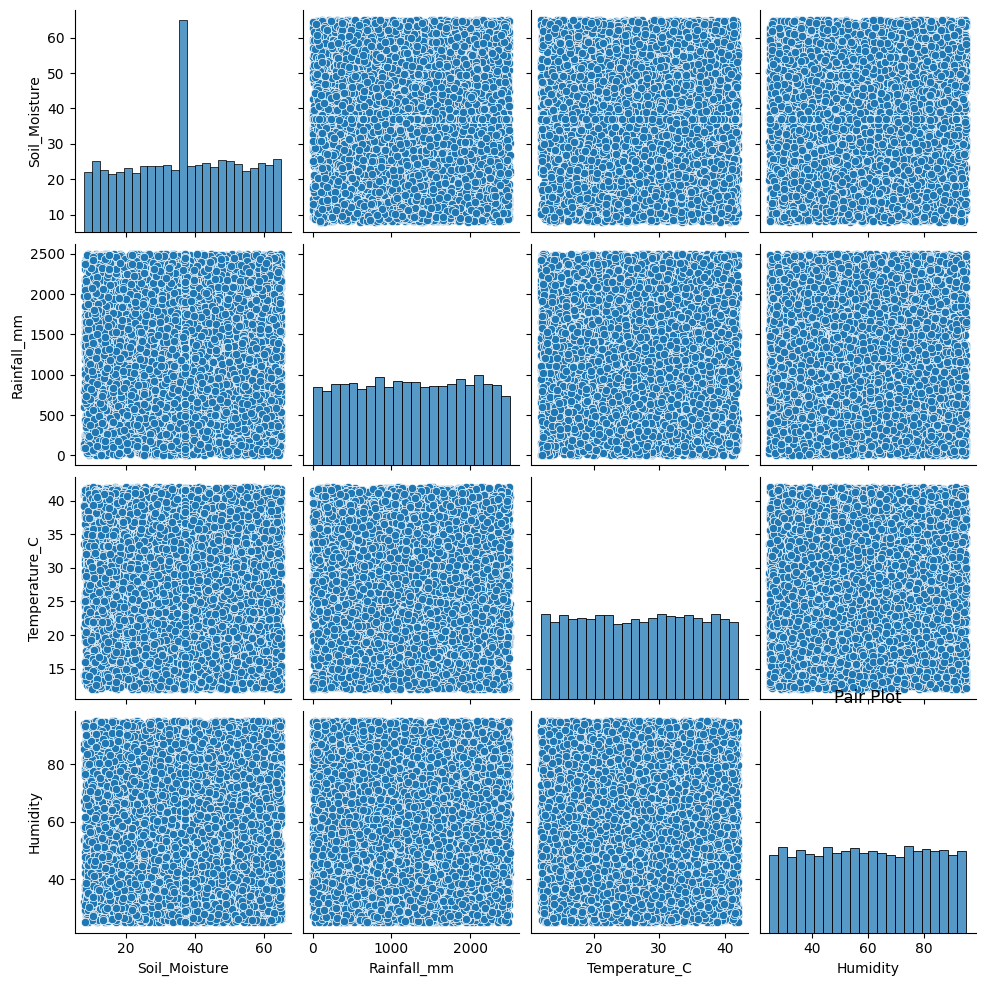

In [ ]:
columns = ["Soil_Moisture",
           "Rainfall_mm",
           "Temperature_C",
           "Humidity"]

sns.pairplot(df[columns])
plt.title("Pair Plot")
plt.show()

**Observations:**
- Soil moisture and rainfall show positive relationship.
- Temperature and humidity show moderate variation patterns.
- Rainfall and irrigation need are indirectly related.

**Heatmap**

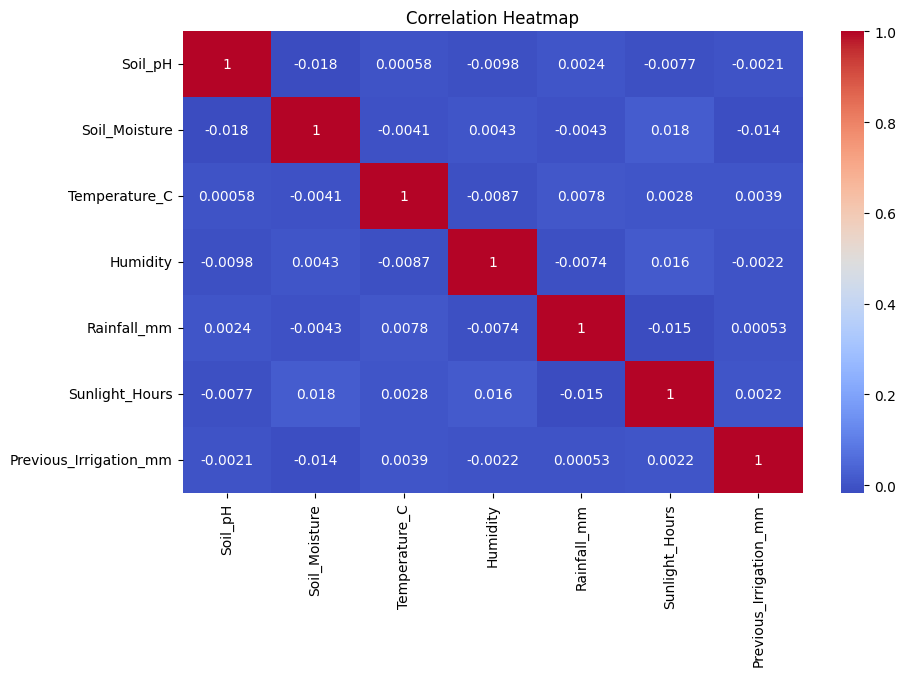

In [ ]:
plt.figure(figsize=(10,6))

sns.heatmap(df.select_dtypes(include=np.number).corr(),
            annot=True,
            cmap="coolwarm")

plt.title("Correlation Heatmap")
plt.show()

**Observations:**
- Rainfall and soil moisture show positive correlation.
- Temperature negatively affects soil moisture.
- Humidity moderately supports soil moisture retention.

**Insights:**
- Higher rainfall and humidity reduce irrigation dependency.
- High temperature increases evaporation and irrigation demand.
- Irrigation requirement is influenced by multiple environmental factors collectively.

# **Final Observations**

**Key Observations:**
- Soil moisture is inversely proportional to irrigation need.
- Low rainfall regions require more irrigation.
- High temperature increases irrigation dependency.
- Sandy soil requires more irrigation due to low water retention.
- Seasonal changes significantly affect irrigation patterns.
- Crop type influences irrigation demand.

# **Key Insights**
1. Soil Moisture is the Most Important Factor

- Lower soil moisture directly increases irrigation requirement.

2. Rainfall Reduces Irrigation Dependency

Natural rainfall decreases artificial irrigation needs.

3. High Temperature Increases Water Demand

Higher temperatures increase evaporation and crop water consumption.

4. Sandy Soil Needs More Irrigation

Sandy soil loses water quickly due to poor retention capacity.

5. Seasonal Variations Affect Irrigation

Kharif season shows higher irrigation demand due to crop and climate conditions.

# **Recommendations**
- Improve Smart Irrigation Systems
- Optimize Water Usage
- Crop-Based Irrigation Planning
- Climate-Based Irrigation Management


# **Conclusion**

This irrigation analysis project studied the environmental and agricultural factors affecting irrigation requirements.

The analysis revealed that:

- Soil moisture is the strongest indicator of irrigation need.
- Rainfall significantly reduces irrigation dependency.
- High temperature increases crop water demand.
- Soil type and seasonal variations strongly influence irrigation decisions.

Overall, efficient irrigation planning using environmental data can help optimize water usage, improve crop productivity, and support sustainable agriculture.